# Tutorial 2: Architectural Discovery with Block-Based Search

In the previous tutorial, we fine-tuned a known architecture (MLP). But what if the best architecture for our problem is a combination of different diverse layer types?

In this notebook, we'll unleash SNAC-pack to **discover new architectures** by combining building blocks like **Convolutional layers**, **Attention**, and **MLPs**.

## The New Challenge

Since we are building arbitrary structures, our hardware estimator may not be accurate. We will instead optimize for two hardware-agnostic objectives:
1.  **Accuracy** (Maximize)
2.  **Computational Cost (BOPs)** (Minimize)

In [ ]:

# Basic imports and setup
import os
import yaml

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import SNAC-pack utilities
from utils.tf_global_search5 import GlobalSearchTF
from utils.tf_visualization import plot_interactive_2d_pareto
from utils.tf_local_search1 import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist



# --- Configuration ---
N_TRIALS_HYBRID = 15 # Note: Increase for a real search
EPOCHS_HYBRID = 15
SUBSET_SIZE_HYBRID = 30000
RESULTS_DIR_HYBRID = "./results/tutorial2_Hybrid_Discovery"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'
RESIZE_VAL = 16

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

2025-08-31 13:54:48.722171: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (30000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (30000,), y_val shape: (10000,)


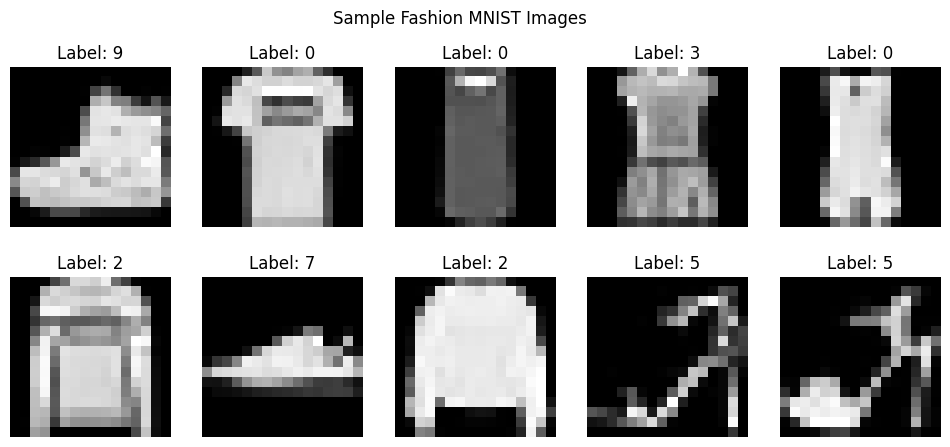

In [2]:

# Load the data for visualization (un-flattened)
x_train_viz, y_train_viz, _, _ = load_and_preprocess_fashion_mnist(
    resize_val=RESIZE_VAL,
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False, 
    one_hot=False
)

# Visualize the first 10 images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample Fashion MNIST Images")
plt.show()

## Global Search: Building with Blocks

We first define a `search_space` in a YAML file. This file provides SNAC-pack with the "Lego bricks" it can use to build and test new architectures. We'll allow it to choose between `Conv`, `MLP`, and `ConvAttn` blocks.


In [3]:

# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
channel_space: [8, 16, 32]
mlp_width_space: [32, 64, 128]
kernel_space: [1, 3, 5]
act_space: ["ReLU", "GELU", "LeakyRelu"]
norm_space: [null, "batch", "layer"]
block_types: ["Conv", "MLP", "None"]
num_blocks: 8
initial_img_size: 16
output_dim: 10
"""

with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops']
MAXIMIZE_FLAGS_HYBRID = [True, False]

# --- Run the Hybrid Search ---
print("\n" + "="*50)
print("Running Part 2: Hybrid Architecture Global Search...")
print("This will take several minutes...")
print("="*50)

searcher_hybrid = GlobalSearchTF(search_space_path=SEARCH_SPACE_PATH, results_dir=RESULTS_DIR_HYBRID)

study_hybrid = searcher_hybrid.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='fashion_mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_hybrid.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    one_hot=True,
)

print("\nGlobal Search Complete!")

Created search space configuration file: hybrid_search_space.yaml

Running Part 2: Hybrid Architecture Global Search...
This will take several minutes...

Starting BLOCK Global Search on FASHION_MNIST



[I 2025-08-31 13:54:53,399] A new study created in memory with name: no-name-55fcb8d3-5ea9-4cde-a4b3-af7fb317bdba


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (30000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (30000, 10), y_val shape: (10000, 10)


[I 2025-08-31 13:56:33,657] Trial 0 finished with values: [0.7077000141143799, 1552875520.0] and parameters: {'b0': 'None', 'b1': 'Conv', 'b2': 'Conv', 'b3': 'Conv', 'b4': 'None', 'b5': 'None', 'b6': 'Conv', 'b7': 'None', 'b1_Conv_channels_0': 2, 'b1_Conv_channels_1': 2, 'b1_Conv_kernels_0': 1, 'b1_Conv_kernels_1': 3, 'b1_Conv_acts_0': 'LeakyRelu', 'b1_Conv_acts_1': 'ReLU', 'b1_Conv_norms_0': 'batch', 'b1_Conv_norms_1': 'batch', 'b2_Conv_channels_0': 0, 'b2_Conv_channels_1': 1, 'b2_Conv_kernels_0': 5, 'b2_Conv_kernels_1': 3, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'LeakyRelu', 'b2_Conv_norms_0': 'layer', 'b2_Conv_norms_1': 'batch', 'b3_Conv_channels_0': 1, 'b3_Conv_channels_1': 2, 'b3_Conv_kernels_0': 1, 'b3_Conv_kernels_1': 1, 'b3_Conv_acts_0': 'GELU', 'b3_Conv_acts_1': 'LeakyRelu', 'b3_Conv_norms_0': 'layer', 'b3_Conv_norms_1': 'batch', 'b6_Conv_channels_0': 1, 'b6_Conv_channels_1': 1, 'b6_Conv_kernels_0': 1, 'b6_Conv_kernels_1': 5, 'b6_Conv_acts_0': 'LeakyRelu', 'b6_Conv_acts_1'

Trial 0: Accuracy=0.7077, BOPs=1552875520


...

Trial 12: Accuracy=0.1000, BOPs=257589248


[I 2025-08-31 14:01:04,237] Trial 13 finished with values: [0.7967000007629395, 146636800.0] and parameters: {'b0': 'None', 'b1': 'None', 'b2': 'Conv', 'b3': 'MLP', 'b4': 'None', 'b5': 'None', 'b6': 'None', 'b7': 'None', 'b2_Conv_channels_0': 0, 'b2_Conv_channels_1': 0, 'b2_Conv_kernels_0': 1, 'b2_Conv_kernels_1': 3, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'ReLU', 'b2_Conv_norms_0': 'batch', 'b2_Conv_norms_1': 'layer', 'b3_MLP_units': 0, 'b3_MLP_act': 'GELU', 'b3_MLP_norm': 'batch', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'layer'}.


Trial 13: Accuracy=0.7967, BOPs=146636800


[I 2025-08-31 14:01:18,085] Trial 14 finished with values: [0.7573999762535095, 47448064.0] and parameters: {'b0': 'MLP', 'b1': 'None', 'b2': 'Conv', 'b3': 'Conv', 'b4': 'None', 'b5': 'Conv', 'b6': 'None', 'b7': 'MLP', 'b0_MLP_units': 0, 'b0_MLP_act': 'LeakyRelu', 'b0_MLP_norm': None, 'b7_MLP_units': 2, 'b7_MLP_act': 'GELU', 'b7_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'layer', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 14: Accuracy=0.7574, BOPs=47448064

CSV results saved to ./results/tutorial2_Hybrid_Discovery/block_search_results.csv

🏆 Best model architecture (Trial 13) saved for local search:
   - Source: ./results/tutorial2_Hybrid_Discovery/trial_13_arch.yaml
   - Destination: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml
   - Accuracy: 0.7967

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 2):
  Values: {'performance_metric': 0.7874000072479248, 'bops': 21626880.0}
  Params: {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3': 'Conv', 'b4': 'Conv', 'b5': 'Conv', 'b6': 'None', 'b7': 'Conv', 'b0_MLP_units': 0, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': 'layer', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}

Rank 2 (Trial 8):
  Values: {'performance_metric': 0.7907000184059143, 'bops': 41549824.0}
  Params: {'b0': 'Non

## Analyzing the Global Search Results

The search has finished exploring different architectural combinations. Let's see what it found!

In [4]:


results_df_hybrid = pd.DataFrame(searcher_hybrid.results)

if not results_df_hybrid.empty:
    # --- Inspect the Best Discovered Architecture ---
    print("--- Best Discovered Architecture (by Accuracy) ---")
    best_trial_row = results_df_hybrid.loc[results_df_hybrid['performance_metric'].idxmax()]
    print(f"Trial Number: {best_trial_row['trial']}")
    print(f"Accuracy: {best_trial_row['performance_metric']:.4f}")
    print(f"BOPs: {best_trial_row['bops']:.2e}")

    # Load and print the architecture from its YAML file
    with open(best_trial_row['yaml_path'], 'r') as f:
        best_arch_yaml = yaml.safe_load(f)

    print("\nArchitecture components:")
    for component in best_arch_yaml['architecture']['components']:
        print(f"- Type: {component['block_type']}, Name: {component['name']}")

    # --- Visualize the Pareto Front (Accuracy vs BOPs) ---
    print("\n--- Generating Interactive Pareto Front Plot for Hybrid Search ---")
    # REPLACE THE OLD PLOTTING FUNCTION WITH THE NEW ONE
    plot_interactive_2d_pareto(
        results_df_hybrid,
        list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID)),
        save_dir=searcher_hybrid.results_dir
    )
else:
    print("Hybrid search did not yield any results to analyze.")

--- Best Discovered Architecture (by Accuracy) ---
Trial Number: 13
Accuracy: 0.7967
BOPs: 1.47e+08

Architecture components:
- Type: Conv, Name: conv_block_2
- Type: Flatten, Name: initial_flatten
- Type: MLP, Name: mlp_block_3
- Type: MLP, Name: classifier_head

--- Generating Interactive Pareto Front Plot for Hybrid Search ---


Interactive 2D Pareto front plot saved to ./results/tutorial2_Hybrid_Discovery/interactive_pareto_front_2d.html


## Local Search: Compressing Our New Discovery

Just like before, the global search saved the best model. We will now apply the same powerful QAT and pruning techniques to this newly discovered hybrid model, demonstrating the consistent workflow of SNAC-pack.


In [8]:

# --- Configuration for Local Search ---
LOCAL_SEARCH_RESULTS_DIR = os.path.join(RESULTS_DIR_HYBRID, "local_search")
LOCAL_SEARCH_CONFIG_PATH = os.path.join(RESULTS_DIR_HYBRID, 'local_search_settings.yaml')

# Define settings for QAT and pruning
local_search_settings = {
    'precision_pairs': [
        {'total_bits': 16, 'int_bits': 6},
        {'total_bits': 8, 'int_bits': 3},
        {'total_bits': 4, 'int_bits': 1},
    ],
    'pruning_iterations': 5,
    'epochs_per_iteration': 5,
    'pruning_rate': 0.8,
}

# Write the settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

# --- Load Dataset for Local Search ---
resize_val = searcher_hybrid.search_space.get('initial_img_size', 11)
x_train, y_train, x_val, y_val = load_and_preprocess_fashion_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False,
    one_hot=True
)

# --- Run the Local Search ---
if os.path.exists(ARCHITECTURE_YAML_PATH):
    local_search_df_hybrid = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    local_search_df_hybrid = pd.DataFrame()

Created local search configuration file: ./results/tutorial2_Hybrid_Discovery/local_search_settings.yaml
Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (30000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (30000, 10), y_val shape: (10000, 10)

 STARTING LOCAL SEARCH STAGE 
--- Loading model architecture from: ./results/tutorial2_Hybrid_Discovery/best_model_for_local_search.yaml ---
--- Model successfully reconstructed ---
Model: "BlockArchitecture"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 16, 16, 1)]       0         
                                                                 
 conv_block_2 (Sequential)   (None, 14, 14, 8)         648       
                                                                 
 initial_flatten (Flatten)   (None, 1568)              0         
                                                     

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning:

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.




--- Pruning Iteration 1/5 | Target Sparsity: 0.2000 ---
Epoch 1/5
235/235 [==============================] - 6s 12ms/step - loss: 1.8011 - accuracy: 0.6283 - val_loss: 0.8757 - val_accuracy: 0.7245
Epoch 2/5
235/235 [==============================] - 2s 10ms/step - loss: 0.7625 - accuracy: 0.7586 - val_loss: 0.7672 - val_accuracy: 0.7689
Epoch 3/5
235/235 [==============================] - 2s 10ms/step - loss: 0.7528 - accuracy: 0.7752 - val_loss: 0.7809 - val_accuracy: 0.7879
Epoch 4/5
235/235 [==============================] - 2s 11ms/step - loss: 0.6727 - accuracy: 0.7934 - val_loss: 0.6734 - val_accuracy: 0.8085
Epoch 5/5
235/235 [==============================] - 2s 10ms/step - loss: 0.8608 - accuracy: 0.7406 - val_loss: 1.2529 - val_accuracy: 0.6218
Iteration 1 Accuracy: 0.6218
--> New best accuracy for this precision: 0.6218

--- Pruning Iteration 2/5 | Target Sparsity: 0.3600 ---
Epoch 1/5
235/235 [==============================] - 6s 12ms/step - loss: 1.8011 - accuracy: 0.628

## Analyzing the Local Search Results

Finally, let's visualize the accuracy/sparsity trade-off for our discovered and compressed model.


In [6]:
# if not local_search_df_hybrid.empty:
#     plt.figure(figsize=(10, 6))
    
#     # Define distinct colors and markers
#     colors = ['blue', 'red']
#     markers = ['o', 's']  # circle and square
    
#     precisions = local_search_df_hybrid['Precision'].unique()
    
#     for i, prec in enumerate(precisions):
#         subset = local_search_df_hybrid[local_search_df_hybrid['Precision'] == prec]
#         print(f"Precision {prec}: {len(subset)} data points")
#         print(subset[['Iteration', 'Sparsity', 'Accuracy']].to_string())
        
#         plt.plot(subset['Sparsity'], subset['Accuracy'], 
#                 marker=markers[i], linestyle='-', 
#                 color=colors[i], linewidth=2,
#                 markersize=8, label=f'Precision {prec}')
    
#     plt.title('Accuracy vs. Sparsity during Local Search')
#     plt.xlabel('Model Sparsity')
#     plt.ylabel('Validation Accuracy')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()
# else:
#     print("Local search did not produce results to analyze.")


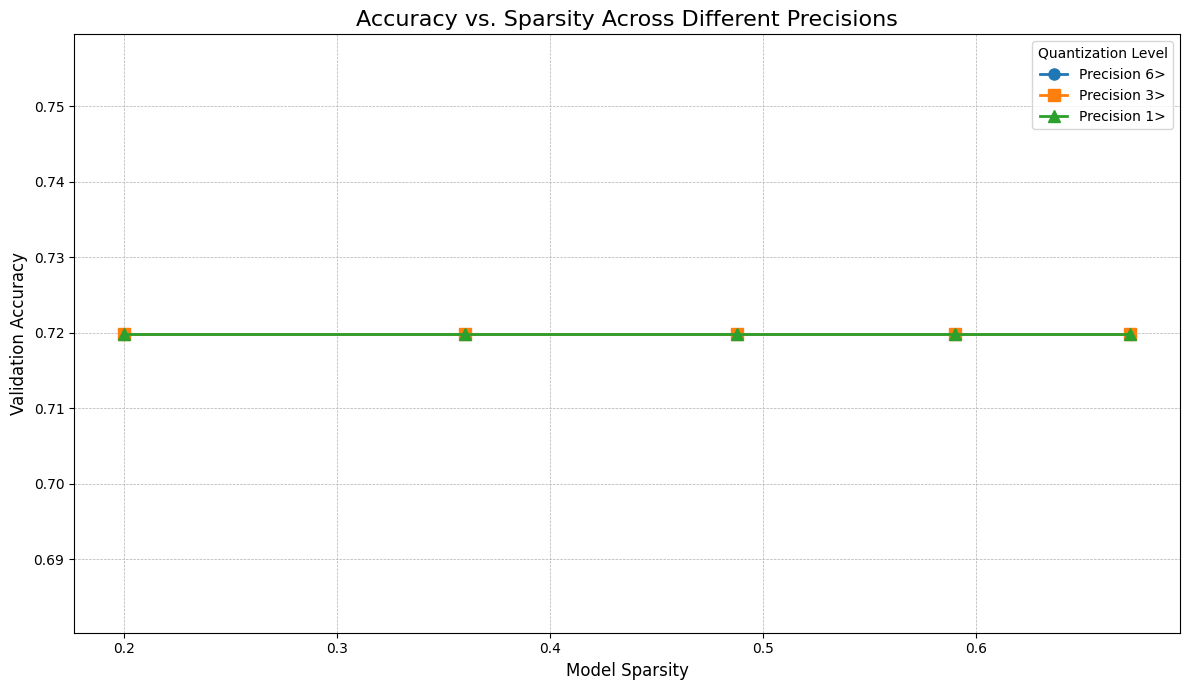

In [7]:
if 'local_search_df_hybrid' in locals() and not local_search_df_hybrid.empty:
    plt.figure(figsize=(12, 7))
    
    # Define distinct colors and markers for better readability
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
    markers = ['o', 's', '^', 'D']  # Circle, Square, Triangle, Diamond
    
    # Get the unique precision levels from the results
    precisions = local_search_df_hybrid['Precision'].unique()
    
    # Plot a separate, styled line for each precision
    for i, prec in enumerate(precisions):
        subset = local_search_df_hybrid[local_search_df_hybrid['Precision'] == prec]
        
        # Sort by sparsity to ensure the line is drawn correctly
        subset = subset.sort_values(by='Sparsity')
        
        plt.plot(subset['Sparsity'], subset['Accuracy'], 
                 marker=markers[i % len(markers)],  # Cycle through markers
                 linestyle='-', 
                 color=colors[i % len(colors)],    # Cycle through colors
                 linewidth=2,
                 markersize=8, 
                 label=f'Precision {prec}')

    plt.title('Accuracy vs. Sparsity Across Different Precisions', fontsize=16)
    plt.xlabel('Model Sparsity', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.legend(title="Quantization Level", fontsize=10)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # plt.ylim(bottom=max(0, local_search_df_hybrid['Accuracy'].min() - 0.05)) # Adjust y-axis to focus on results
    plt.tight_layout()
    plt.show()
else:
    print("Local search did not produce results to analyze.")